Importo las librerías para trabajar ETL y EDA

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import math
sns.set_style('whitegrid')
sns.set_palette('tab10')
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode,iplot
import datetime as dato
plt.style.use('seaborn-notebook')
import warnings
warnings.filterwarnings('ignore')
from ydata_profiling import ProfileReport
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')


Ingesta de archivos csv

In [2]:
dfml=pd.read_csv(r'/Users/herminiaaguirre/Desktop/Henry/Proyectos varios/4.PI/MLOps/ML_ETL_plataformas.csv') 

In [3]:
dfmlr1=pd.read_csv(r'/Users/herminiaaguirre/Desktop/Henry/Proyectos varios/4.PI/MLOps/datasets/ratings/1.csv')
dfmlr2=pd.read_csv(r'/Users/herminiaaguirre/Desktop/Henry/Proyectos varios/4.PI/MLOps/datasets/ratings/2.csv')
dfmlr3=pd.read_csv(r'/Users/herminiaaguirre/Desktop/Henry/Proyectos varios/4.PI/MLOps/datasets/ratings/3.csv')
dfmlr4=pd.read_csv(r'/Users/herminiaaguirre/Desktop/Henry/Proyectos varios/4.PI/MLOps/datasets/ratings/4.csv')
dfmlr5=pd.read_csv(r'/Users/herminiaaguirre/Desktop/Henry/Proyectos varios/4.PI/MLOps/datasets/ratings/5.csv')
dfmlr6=pd.read_csv(r'/Users/herminiaaguirre/Desktop/Henry/Proyectos varios/4.PI/MLOps/datasets/ratings/6.csv')
dfmlr7=pd.read_csv(r'/Users/herminiaaguirre/Desktop/Henry/Proyectos varios/4.PI/MLOps/datasets/ratings/7.csv')
dfmlr8=pd.read_csv(r'/Users/herminiaaguirre/Desktop/Henry/Proyectos varios/4.PI/MLOps/datasets/ratings/8.csv')

In [4]:
dfmlr=(pd.concat([dfmlr1,dfmlr2,dfmlr3,dfmlr4,dfmlr5,dfmlr6,dfmlr7,dfmlr8], axis=0))

In [5]:
dfml.shape

(22998, 17)

In [6]:
dfmlr.shape

(11024289, 4)

Arranco el proceso de EDA (Exploraty Data Anaysis)

In [7]:
dfml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22998 entries, 0 to 22997
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             22998 non-null  object 
 1   show_id        22998 non-null  object 
 2   type           22998 non-null  object 
 3   title          22998 non-null  object 
 4   director       22998 non-null  object 
 5   cast           22998 non-null  object 
 6   country        22998 non-null  object 
 7   date_added     22998 non-null  object 
 8   release_year   22998 non-null  int64  
 9   rating         22998 non-null  object 
 10  duration       22998 non-null  object 
 11  listed_in      22998 non-null  object 
 12  description    22998 non-null  object 
 13  plataforma     22998 non-null  object 
 14  duration_int   22998 non-null  int64  
 15  duration_type  22998 non-null  object 
 16  score          19488 non-null  float64
dtypes: float64(1), int64(2), object(14)
memory usage: 

In [8]:
dfml.sample(2)

,id,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,plataforma,duration_int,duration_type,score
1636,as1637,s1637,tv show,momo let's be nice,Sin dato,Sin dato,Sin dato,Sin dato,2014,TV-Y,2 Seasons,tv shows,learn tradtional chinese social skills such as...,amazon,2,Seasons,3.524558
22959,ns8769,s8769,movie,y tu mamá también,alfonso cuarón,"maribel verdú, gael garcía bernal, diego luna,...",mexico,2017-06-01 00:00:00,2001,R,106 min,"dramas, independent movies, international movies",when rich teens tenoch and julio meet the allu...,netflix,106,min,3.451509


In [9]:
dfmlr.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11024289 entries, 0 to 1499999
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   rating     float64
 2   timestamp  int64  
 3   movieId    object 
dtypes: float64(1), int64(2), object(1)
memory usage: 420.5+ MB


In [10]:
dfmlr.sample(2)

,userId,rating,timestamp,movieId
1034674,10542,4.0,1044049443,ns865
1110836,27168,5.0,1228383453,ns6911


Busco y sumo valores nulos

In [11]:
dfml.isna().sum()

id                  0
show_id             0
type                0
title               0
director            0
cast                0
country             0
date_added          0
release_year        0
rating              0
duration            0
listed_in           0
description         0
plataforma          0
duration_int        0
duration_type       0
score            3510
dtype: int64

In [12]:
dfmlr.isna().sum()

userId       0
rating       0
timestamp    0
movieId      0
dtype: int64

Elimino colmnas innecesarias : 'show_id', 'description'

In [18]:
dfml = dfml.drop('show_id',axis=1)

In [20]:
dfml = dfml.drop('description',axis=1)

In [22]:
dfml.shape

(22998, 15)

Renombro la columna genero

In [49]:
dfml = dfml.rename(columns={'listed_in':'genre'})
dfml.sample(10)

,id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,plataforma,duration_int,duration_type,score
19694,ns5504,movie,jfk: the making of a president,edward cotterill,Sin dato,united kingdom,2017-05-01 00:00:00,2017,TV-PG,44 min,documentaries,netflix,44,min,NaN
7618,as7619,movie,lon chaney in the unholy three - the original ...,tod browning,"lon chaney, victor mclaglen, harry earles, mae...",Sin dato,Sin dato,1925,13+,86 min,action,amazon,86,min,3.545455
125,as126,movie,when did you last see your father?,anand tucker,"jim broadbent, colin firth, gina mckee",Sin dato,Sin dato,2008,PG-13,92 min,arthouse,amazon,92,min,3.500000
17819,ns3629,movie,léa & i,camille shooshani,"léa moret, camille shooshani",Sin dato,2019-08-02 00:00:00,2019,TV-MA,84 min,documentaries,netflix,84,min,3.603000
17460,ns3270,tv show,i'm with the band: nasty cherry,Sin dato,"charli xcx, emmie lichtenberg, gabbriette bech...",united states,2019-11-15 00:00:00,2019,TV-MA,1 Season,reality tv,netflix,1,Season,3.501114
7321,as7322,tv show,cam & leon,Sin dato,Sin dato,Sin dato,Sin dato,2017,ALL,1 Season,animation,amazon,1,Season,NaN
5806,as5807,movie,manifest destiny: the lewis & clark musical ad...,anthony parisi,"jeremy hoffman, kev abrams, jesse grotholson, ...",Sin dato,Sin dato,2016,13+,87 min,comedy,amazon,87,min,NaN
18160,ns3970,tv show,traitors,Sin dato,"emma appleton, michael stuhlbarg, luke treadaw...",united kingdom,2019-03-29 00:00:00,2019,TV-MA,1 Season,british tv shows,netflix,1,Season,3.563265
364,as365,movie,third eye spies,lance mungia,"russell targ, dean radin phd, uri geller, bria...",Sin dato,Sin dato,2019,13+,115 min,documentary,amazon,115,min,3.491379
8581,as8582,movie,i'm not there,todd haynes,"christian bale, cate blanchett, richard gere, ...",Sin dato,Sin dato,2007,R,136 min,arts,amazon,136,min,NaN


In [26]:
dfml['genre'] = dfml['genre'].apply(lambda x: x.split(",")[0])


In [27]:
dfml['genre'].head()

0         comedy
1          drama
2         action
3    documentary
4          drama
Name: genre, dtype: object

Agrego una nueva columna con el año de subida a la plataforma

In [34]:
dfml['release_year'] = dfml['release_year'].astype(str).apply(lambda x: x.split(" ")[-1])
dfml['release_year'].head()

0    2014
1    2018
2    2017
3    2014
4    1989
Name: release_year, dtype: object

In [41]:
dfml['country'] = dfml['country'].apply(lambda x: x.split('.')[0])
dfml['country'].head()

0            canada
1             india
2     united states
3     united states
4    united kingdom
Name: country, dtype: object

Aca cuento y transformo en porcentaje el tipo de contenido

In [46]:
count = dfml['type'].value_counts()
percent = 100*dfml['type'].value_counts(normalize=True)
pd.DataFrame({'count': count, 'percent': percent.round(0)})

,count,percent
movie,16481,72.0
tv show,6517,28.0


Aca cuento y transformo en porcentaje el rating

In [51]:
count = dfml['rating'].value_counts()
percent = 100*dfml['rating'].value_counts(normalize=True)
pd.DataFrame({'count': count, 'percent': percent.round(0)})

,count,percent
TV-MA,3675,16.0
TV-14,3138,14.0
R,2154,9.0
13+,2117,9.0
TV-PG,1654,7.0
...,...,...
119 min,1,0.0
115 min,1,0.0
136 min,1,0.0
61 min,1,0.0


Divido en 2 nuevos dataframes de acuerdo al type

In [84]:
dfmovie = dfml[dfml['type'] == 'movie']
dfmovie.head()
dfmovie.shape

,id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,plataforma,duration_int,duration_type,score
0,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127
1,as2,movie,take care good night,girish joshi,"mahesh manjrekar, abhay mahajan, sachin khedekar",india,2021-03-30 00:00:00,2018,13+,110 min,drama,amazon,110,min,3.556886
2,as3,movie,secrets of deception,josh webber,"tom sizemore, lorenzo lamas, robert lasardo, r...",united states,2021-03-30 00:00:00,2017,G,74 min,action,amazon,74,min,3.604124
3,as4,movie,pink: staying true,sonia anderson,"interviews with: pink, adele, beyoncé, britney...",united states,2021-03-30 00:00:00,2014,G,69 min,documentary,amazon,69,min,3.547085
4,as5,movie,monster maker,giles foster,"harry dean stanton, kieran o'brien, george cos...",united kingdom,2021-03-30 00:00:00,1989,G,45 min,drama,amazon,45,min,3.532158


(16481, 15)

In [85]:
dfmovie.to_csv('ML_ETL_movies.csv',index=False)

In [83]:
dftv = dfml[dfml['type'] == 'tv show']
dftv.sample(5)
dftv.shape

,id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,plataforma,duration_int,duration_type,score
2176,as2177,tv show,how 2,Sin dato,"fred dinenage, gareth jones, carol vorderman",Sin dato,Sin dato,1990,ALL,1 Season,kids,amazon,1,Season,3.530000
3253,as3254,tv show,angelina ballerina classic,Sin dato,"finty williams, derek jacobi, judi dench, jo w...",Sin dato,Sin dato,2003,TV-Y,3 Seasons,kids,amazon,3,Seasons,3.609780
2720,as2721,tv show,daniel tiger's neighborhood,Sin dato,"jake beale, heather bambrick, ted dykstra",Sin dato,Sin dato,2012,TV-Y,1 Season,kids,amazon,1,Season,3.526946
22701,ns8511,tv show,the sniffer,Sin dato,"kirill käro, ivan oganesyan, mariya anikanova,...",ukraine,2018-06-01 00:00:00,2017,TV-MA,3 Seasons,crime tv shows,netflix,3,Seasons,3.511066
2249,as2250,tv show,harmony with a r rahman,Sin dato,"a r rahman, sajith vijayan, bahauddin dagar, b...",Sin dato,Sin dato,2018,NR,1 Season,arts,amazon,1,Season,3.537578


(6517, 15)

In [ ]:
dftv.to_csv('ML_ETL_tv.csv',index=False)

In [58]:
fig = px.histogram(dfml,
                    x= 'type',
                    template = "plotly_dark",
                    color_discrete_sequence=['forestgreen','darkorange','gold','deeppink'],
                    title= 'Tipo de programas')
fig.update_layout(bargap=0.1)
fig.show();

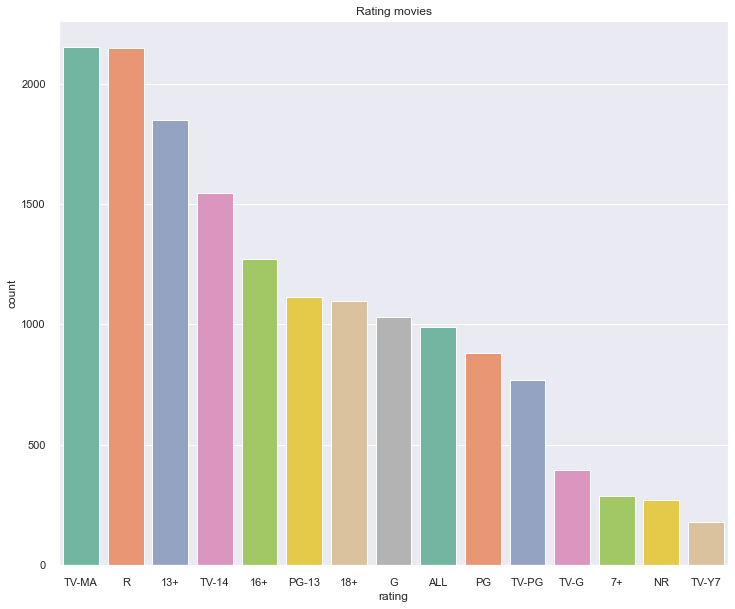

In [63]:
plt.figure(figsize=(12,10))
sns.set(style= 'darkgrid')
sns.countplot(x='rating', data= dfmovie, palette='Set2', order=dfmovie['rating'].value_counts().index[0:15]);
plt.title('Rating movies');

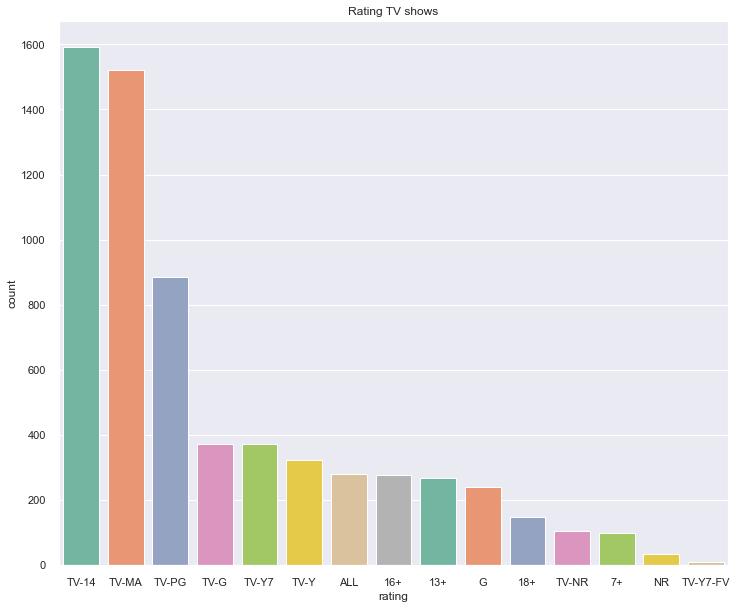

In [65]:
plt.figure(figsize=(12,10))
sns.set(style= 'darkgrid')
sns.countplot(x='rating', data= dftv, palette='Set2', order=dftv['rating'].value_counts().index[0:15]);
plt.title('Rating TV shows');

Analisis del contenido por año

In [ ]:
plt.figure(figsize=(12,10))
sns.set(style='darkgrid')
sns.countplot(y='release_year', dftv, palette=)

Uno los archivos desde la columna 'movieid'

In [68]:
dfcompl = dfml.merge(dfmlr, left_on='id', right_on='movieId', how='outer')

In [14]:
dfcompl.shape

(11024289, 21)

In [15]:
dfcompl.sample(10)

,id,show_id,type,title,director,cast,country,date_added,release_year,rating_x,...,listed_in,description,plataforma,duration_int,duration_type,score,userId,rating_y,timestamp,movieId
1938229,as4042,s4042,movie,woman in the woods,kevin ang,"brian sy, mercedes cabral, lotlot bustamante, ...",Sin dato,Sin dato,2021,G,...,"action, science fiction","when jason's father dies, he goes on an advent...",amazon,88,min,3.463617,20899,2.0,1147688040,as4042
5796093,hs980,s980,tv show,line of duty,Sin dato,Sin dato,united kingdom,2021-02-12 00:00:00,2012,TV-MA,...,"crime, drama, international",set in the fictional police anti-corruption un...,hulu,5,Seasons,3.556723,65743,4.0,1202224941,hs980
5162076,ds1107,s1107,movie,now you see it,duwayne dunham,"alyson michalka, johnny pacar, frank langella,...",united states,2019-11-12 00:00:00,2005,TV-G,...,"coming of age, fantasy",an aspiring tv producer searches for the world...,disney,89,min,3.555118,249225,3.0,1429465937,ds1107
8167438,ns2854,s2854,movie,fat ballerina - david a. arnold,milton horowitz,david a. arnold,united states,2020-03-02 00:00:00,2020,TV-MA,...,stand-up comedy,"finally comfortable in his skin, seasoned comi...",netflix,61,min,3.427350,5942,5.0,851262103,ns2854
9577706,ns5792,s5792,movie,"tomasz jachimek, jacek stramik laugh at live",Sin dato,"tomasz jachimek, jacek stramik",Sin dato,2016-09-19 00:00:00,2016,TV-MA,...,stand-up comedy,"writer, actor and satirist tomasz jachimek tea...",netflix,63,min,3.512371,77309,3.5,1133212803,ns5792
9255324,ns5121,s5121,tv show,cheuk wan-chi: two night stand,Sin dato,cheuk wan chi,Sin dato,2017-12-15 00:00:00,2015,TV-MA,...,"international tv shows, stand-up comedy & talk...",writer and stand-up comedian cheuk wan-chi cra...,netflix,1,Season,3.515730,256341,4.0,1191346691,ns5121
3913456,as8166,s8166,movie,a different kind of christmas,tom mcloughlin,"shelley long, barry bostwick, bruce kirby, nat...",Sin dato,Sin dato,1996,13+,...,drama,what is like to grow up with a dad who truly b...,amazon,92,min,3.481781,53696,3.0,840747306,as8166
5613690,hs600,s600,tv show,jóvenes y rebeldes,Sin dato,Sin dato,Sin dato,2021-06-17 00:00:00,1999,G,...,"comedy, latino",esta comedia dramática nostálgica producida po...,hulu,1,Season,3.495475,26576,3.0,1111527034,hs600
5618513,hs610,s610,movie,gone girl,Sin dato,Sin dato,united states,2021-06-15 00:00:00,2014,TV-MA,...,"crime, drama, mystery",on the occasion of his fifth wedding anniversa...,hulu,146,min,3.537267,14046,5.0,1014314659,hs610
9575593,ns5788,s5788,movie,"katarzyna piasecka, rafał pacześ seriously funny",Sin dato,"katarzyna piasecka, rafał pacześ",Sin dato,2016-09-19 00:00:00,2016,TV-MA,...,stand-up comedy,polish comedians rafał pacześ and katarzyna pi...,netflix,65,min,3.588694,38312,4.0,1478892765,ns5788


In [70]:
dfcompl = dfcompl.replace('Sin dato', pd.np.nan)

In [71]:
dfcompl.tail()

,id,type,title,director,cast,country,date_added,release_year,rating_x,duration,genre,plataforma,duration_int,duration_type,score,userId,rating_y,timestamp,movieId
11024284,ns8807,movie,zubaan,mozez singh,"vicky kaushal, sarah-jane dias, raaghav chanan...",india,2019-03-02 00:00:00,2015,TV-14,111 min,dramas,netflix,111,min,3.514607,122699,4.0,932245868,ns8807
11024285,ns8807,movie,zubaan,mozez singh,"vicky kaushal, sarah-jane dias, raaghav chanan...",india,2019-03-02 00:00:00,2015,TV-14,111 min,dramas,netflix,111,min,3.514607,122869,4.0,1447215782,ns8807
11024286,ns8807,movie,zubaan,mozez singh,"vicky kaushal, sarah-jane dias, raaghav chanan...",india,2019-03-02 00:00:00,2015,TV-14,111 min,dramas,netflix,111,min,3.514607,123708,3.0,1002847728,ns8807
11024287,ns8807,movie,zubaan,mozez singh,"vicky kaushal, sarah-jane dias, raaghav chanan...",india,2019-03-02 00:00:00,2015,TV-14,111 min,dramas,netflix,111,min,3.514607,123841,4.0,991413969,ns8807
11024288,ns8807,movie,zubaan,mozez singh,"vicky kaushal, sarah-jane dias, raaghav chanan...",india,2019-03-02 00:00:00,2015,TV-14,111 min,dramas,netflix,111,min,3.514607,124184,3.0,966611911,ns8807


In [72]:
dfcompl = dfcompl.dropna()

In [73]:
dfcompl.head(20)

,id,type,title,director,cast,country,date_added,release_year,rating_x,duration,genre,plataforma,duration_int,duration_type,score,userId,rating_y,timestamp,movieId
0,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127,543,5.0,1059596582,as1
1,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127,595,3.0,839937603,as1
2,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127,611,3.0,978549108,as1
3,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127,2523,3.5,1340634980,as1
4,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127,3082,4.0,954396636,as1
5,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127,3672,4.5,1053046149,as1
6,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127,3696,2.5,1139622455,as1
7,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127,3894,4.5,1490917472,as1
8,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127,4233,3.5,1280531973,as1
9,as1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,113 min,comedy,amazon,113,min,3.549127,4574,3.5,1225300503,as1


Se analiza a un usuario X en particular

In [16]:
dato = dfcompl.loc[dfcompl['userId']==543]
dato.shape
dato.head(5)

,id,show_id,type,title,director,cast,country,date_added,release_year,rating_x,...,listed_in,description,plataforma,duration_int,duration_type,score,userId,rating_y,timestamp,movieId
0,as1,s1,movie,the grand seduction,don mckellar,"brendan gleeson, taylor kitsch, gordon pinsent",canada,2021-03-30 00:00:00,2014,G,...,"comedy, drama",a small fishing village must procure a local d...,amazon,113,min,3.549127,543,5.0,1059596582,as1
5364,as12,s12,movie,take care,liz tuccillo,"leslie bibb, kevin curtis, nadia dajani",united states,2021-04-10 00:00:00,2014,G,...,comedy,"when a car crash leaves frannie immobilized, s...",amazon,93,min,3.579348,543,3.0,962139925,as12
7739,as17,s17,movie,zoombies,glenn miller,"marcus anderson, kaiwi lyman, andrew asper",Sin dato,Sin dato,2016,13+,...,"horror, science fiction",when a strange virus quickly spreads through a...,amazon,87,min,3.524655,543,3.0,963806452,as17
14391,as31,s31,tv show,yu-gi-oh! 5d's,Sin dato,"gregory abbey, bella hudson, ed paul",Sin dato,Sin dato,2011,TV-Y7,...,"anime, kids",with the defeat of director goodwin and the da...,amazon,2,Seasons,3.522857,543,5.0,943800914,as31
71924,as151,s151,movie,wash your hands & more classic kids songs - ki...,moonbug entertainment,Sin dato,Sin dato,Sin dato,2020,ALL,...,kids,a new collection of colorful and wonderfully e...,amazon,30,min,3.577621,543,1.0,963807270,as151


In [76]:
import sweetviz as sv

In [77]:
my_report = sv.analyze(dfcompl)

                                             |          | [  0%]   00:01 -> (? left)

In [78]:
my_report.show_html()

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
